# Proyek Tugas Akhir: Klasterisasi Lahan Pertanian Berdasarkan Karakteristik Agronomi untuk Sistem Rekomendasi Tanaman Multilabel

## 1. Ringkasan Akademik & Formulasi Masalah

### 1.1 Latar Belakang (Context)
Dalam era pertanian presisi (*precision agriculture*), optimalisasi pemilihan komoditas berdasarkan kecocokan agro-klimatologi lahan sangat penting untuk meningkatkan produktivitas dan menjaga keberlanjutan tanah. Kondisi agronomi lahan ditentukan oleh parameter biofisik tanah (makronutrien Nitrogen [N], Fosfor [P], Kalium [K], dan tingkat keasaman [pH]) serta kondisi mikroklimat (suhu, kelembaban udara, dan curah hujan).

Pada umumnya, permasalahan rekomendasi tanaman didekati dengan metode pembelajaran terawasi klasifikasi multi-kelas (*supervised multi-class classification*) di mana model memetakan parameter tanah ke satu jenis tanaman ($X \to Y$). Namun, secara ekologis dan bisnis pertanian, pendekatan ini terlalu membatasi (*rigid*). Satu karakteristik lahan tertentu sering kali adaptif terhadap lebih dari satu komoditas tanaman. Oleh karena itu, rekomendasi tanaman yang realistis harus dirancang sebagai sistem rekomendasi multilabel (*multilabel crop recommendation*) untuk memfasilitasi petani dalam rotasi tanaman (*crop rotation*), tumpang sari (*intercropping*), dan diversifikasi risiko pertanian.

### 1.2 Formulasi Permasalahan (Problem Formulation)
Kritik utama terhadap pendekatan supervised konvensional yang melandasi urgensi penelitian ini meliputi:
1. **Keterbatasan Output Tunggal (*Single-Label Output Constraint*)**: Model klasifikasi supervised konvensional memprediksi satu tanaman terbaik saja per input lahan. Hal ini meniadakan peluang alternatif komoditas lain yang memiliki toleransi tumbuh serupa di lahan tersebut.
2. **Ketiadaan Dataset Multilabel Aktual (*Lack of Multilabel Labeled Dataset*)**: Dataset publik yang umum digunakan (seperti *Crop Recommendation Dataset*) hanya menyediakan satu label tanaman per baris data. Melakukan pencatatan multilabel secara manual di lapangan membutuhkan biaya tinggi dan waktu yang lama.
3. **Rigiditas Batas Wilayah Lahan (*Rigidity of Land Boundary Decisions*)**: Karakteristik tanah bersifat kontinu dan dinamis. Penggunaan klasterisasi keras (*hard clustering*) seperti K-Means atau K-Medoids menghasilkan pemisahan spasial yang kaku, sehingga kurang mampu menangani area perbatasan klaster (zona transisi). Hal ini memicu perlunya eksplorasi algoritma klasterisasi berbasis probabilitas dan fuzzy.

### 1.3 Solusi Unsupervised & Novelty (Proposed Solution & Value Proposition)
Untuk memecahkan permasalahan di atas, penelitian ini memformulasikan kembali tugas rekomendasi tanaman menjadi masalah **Klasterisasi Unsupervised berbasis Reduksi Dimensi PCA**:
- **Pemetaan Multilabel Alami via Klasterisasi**: Dengan mengelompokkan data lahan tanpa pengawasan label (*unsupervised*), kita mengelompokkan profil tanah yang serupa. Setiap klaster akan menampung beberapa jenis tanaman yang tumbuh subur pada rentang parameter yang berdekatan. Dengan demikian, ketika ada data lahan baru, kita cukup mengidentifikasi klasternya dan menyajikan seluruh varietas tanaman unik di klaster tersebut sebagai rekomendasi multilabel alternatif.
- **Implementasi Klasterisasi Fuzzy & Probabilistik (Soft/Probabilistic Clustering)**: Kami membandingkan algoritma klasterisasi berbasis pusat dan hierarki (*K-Means, K-Medoids, Hierarchical*) dengan metode probabilistik/fuzzy (*GMM dan Fuzzy C-Means*). GMM dan FCM mengekstrak nilai probabilitas posterior atau derajat keanggotaan (*membership degree*) suatu lahan terhadap beberapa klaster sekaligus, memungkinkan sistem memberikan rekomendasi tanaman lintas-klaster (*cross-cluster recommendation*) yang berperingkat (*ranked multilabel*) untuk lahan yang berada di zona transisi.
- **Kebijakan Pemeliharaan Outlier**: Kami mempertahankan outlier statistik terdeteksi karena dalam domain pertanian, pencilan data agronomi mencerminkan kebutuhan biologis ekstrim yang sah dari komoditas bernilai tinggi (misalnya: apel/anggur membutuhkan kalium sangat tinggi, padi membutuhkan curah hujan sangat tinggi). Penghapusan outlier akan melenyapkan varietas tanaman ini dari taksonomi model.

**Alur Analisis:**
1. Import Library
2. Data Loading
3. Data Understanding
4. Data Cleaning & Outlier Analysis
5. Exploratory Data Analysis (EDA)
6. Data Preprocessing (Scaling)
7. Feature Engineering (Principal Component Analysis - PCA)
8. Training Model (K-Means Clustering)
9. Training Model Pembanding (K-Medoids, GMM, Hierarchical, Fuzzy C-Means)
10. Evaluasi Model Komparatif (Silhouette Score, Davies-Bouldin Index, Adjusted Rand Index)
11. Visualisasi Hasil Klasterisasi (2D & 5D)
12. Analisis & Interpretasi Karakteristik Centroid Klaster
13. Kesimpulan dan Saran

## 1. Import Library
Memuat semua pustaka yang dibutuhkan untuk manipulasi data, visualisasi, dan pemodelan machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
import skfuzzy as fuzz
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# Pengaturan visualisasi & peringatan
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Data Loading
Memuat dataset `crop_recommendation.csv` ke dalam Pandas DataFrame.

In [2]:
# Load dataset
try:
    df = pd.read_csv('crop_recommendation.csv')
except:
    df = pd.read_csv('../crop_recommendation.csv')

# Menampilkan 5 baris pertama dataset
display(df.head())


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3. Data Understanding
Menganalisis struktur data, tipe data, dan statistik deskriptif awal.

In [3]:
# Informasi umum dataset
print("Informasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe())

print("\nDistribusi Label (Jenis Tanaman):")
display(df['label'].value_counts())


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

Statistik Deskriptif:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117



Distribusi Label (Jenis Tanaman):


label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

### Visualisasi Distribusi Target Label (Tanaman)
Grafik batang di bawah ini menunjukkan penyebaran jumlah data sampel untuk masing-masing kelas tanaman dalam dataset.

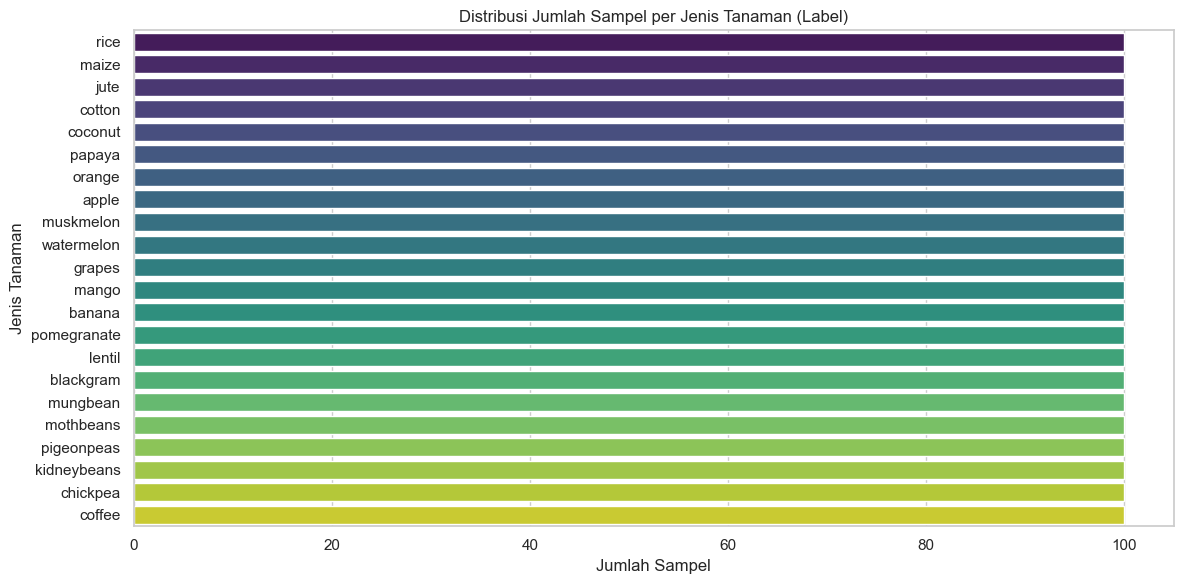

In [4]:
# Visualisasi Distribusi Jumlah Data per Jenis Tanaman
plt.figure(figsize=(12, 6))
sns.countplot(y='label', data=df, order=df['label'].value_counts().index, palette='viridis')
plt.title('Distribusi Jumlah Sampel per Jenis Tanaman (Label)')
plt.xlabel('Jumlah Sampel')
plt.ylabel('Jenis Tanaman')
plt.tight_layout()
plt.show()


## 4. Data Cleaning
Memeriksa adanya *missing values* (nilai yang hilang) dan data duplikat.

In [5]:
# Cek Missing Values
print("Jumlah Missing Values per Kolom:")
print(df.isnull().sum())

# Cek Duplikasi
duplicates = df.duplicated().sum()
print(f"\nJumlah data duplikat: {duplicates}")

# Menghapus duplikat jika ada
if duplicates > 0:
    df = df.drop_duplicates()
    print("Data duplikat telah dihapus.")
else:
    print("Tidak ada data duplikat.")


Jumlah Missing Values per Kolom:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Jumlah data duplikat: 0
Tidak ada data duplikat.


## 5. Exploratory Data Analysis (EDA)
Melakukan analisis univariat dan bivariat untuk memahami distribusi dan hubungan antar fitur.

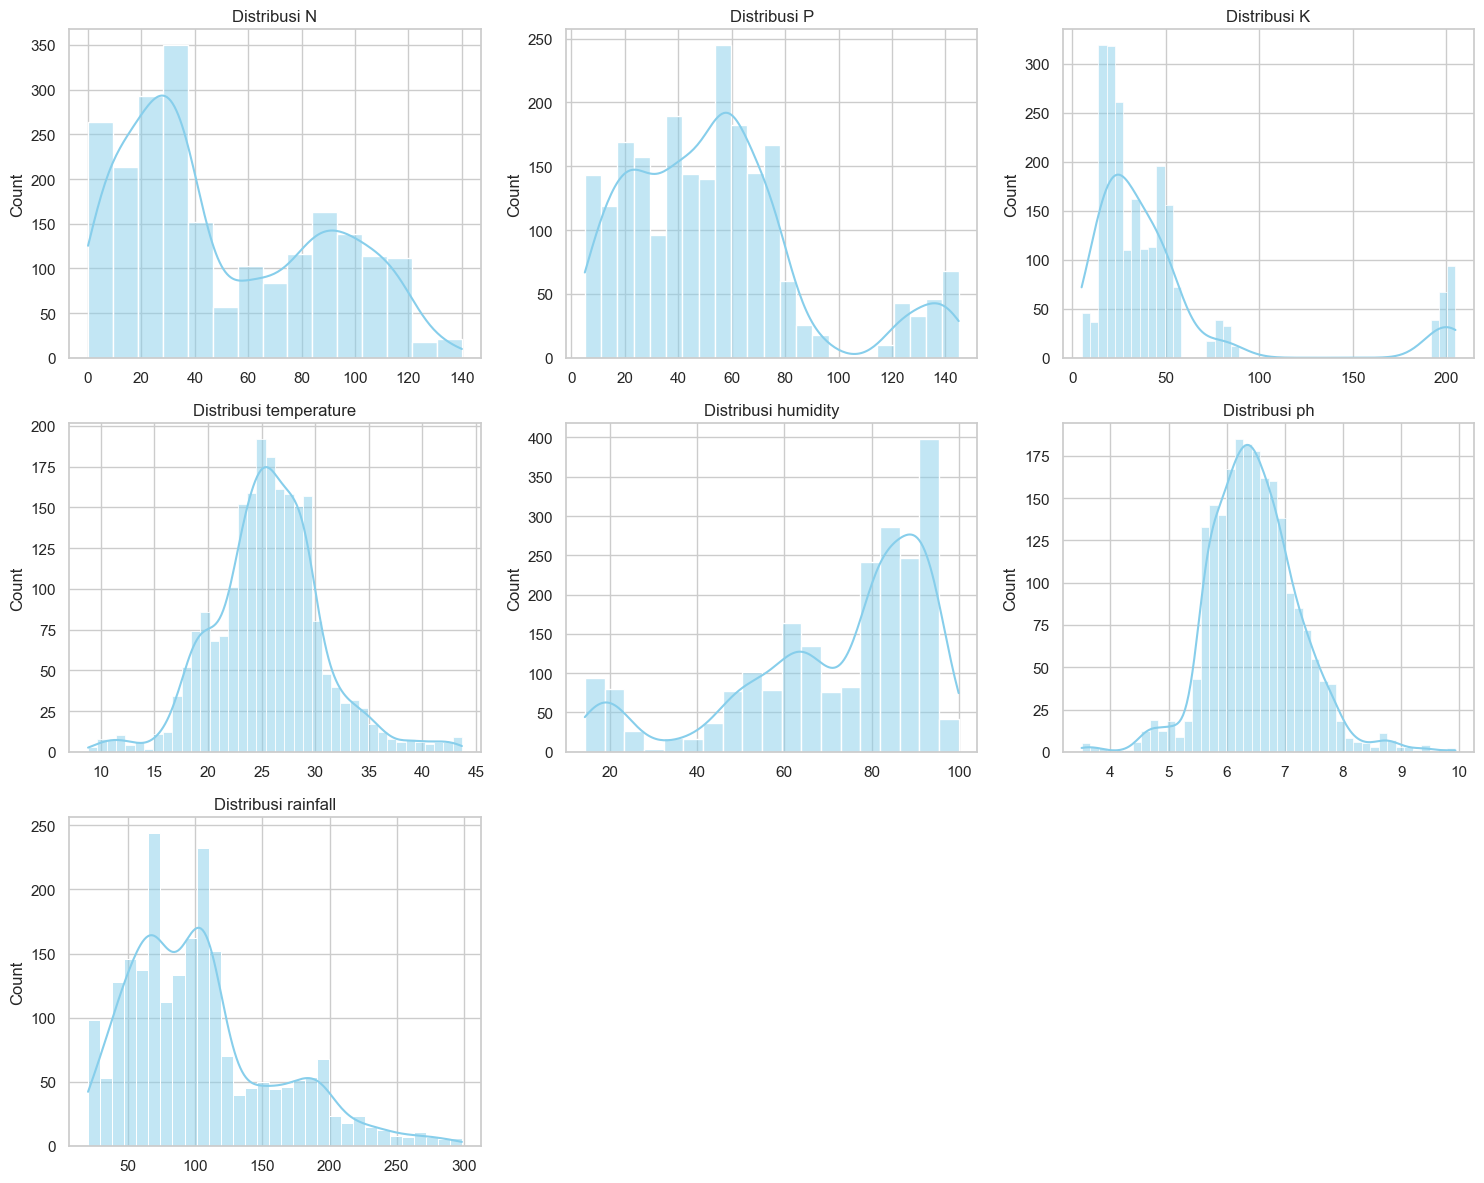

In [6]:
# Distribusi fitur numerik (Univariat)
numeric_cols = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel('')
    
# Hapus axis yang kosong
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


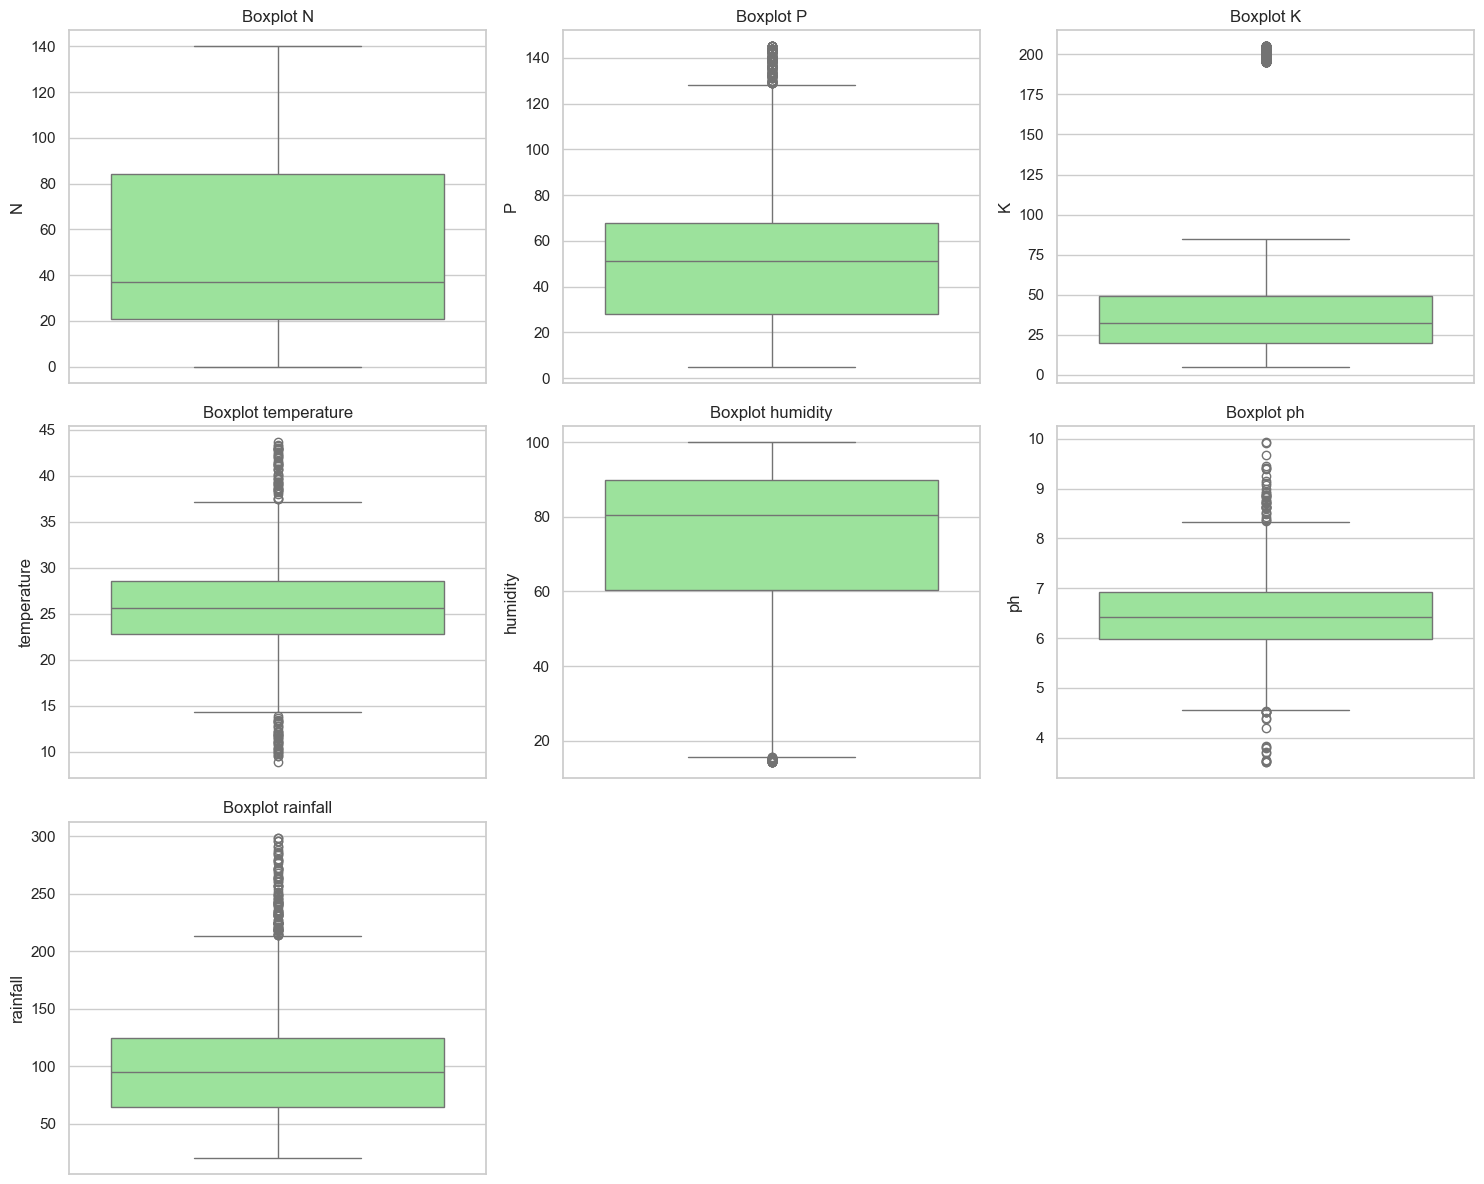

In [7]:
# Deteksi Outlier menggunakan Boxplot
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot {col}')
    
# Hapus axis yang kosong
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


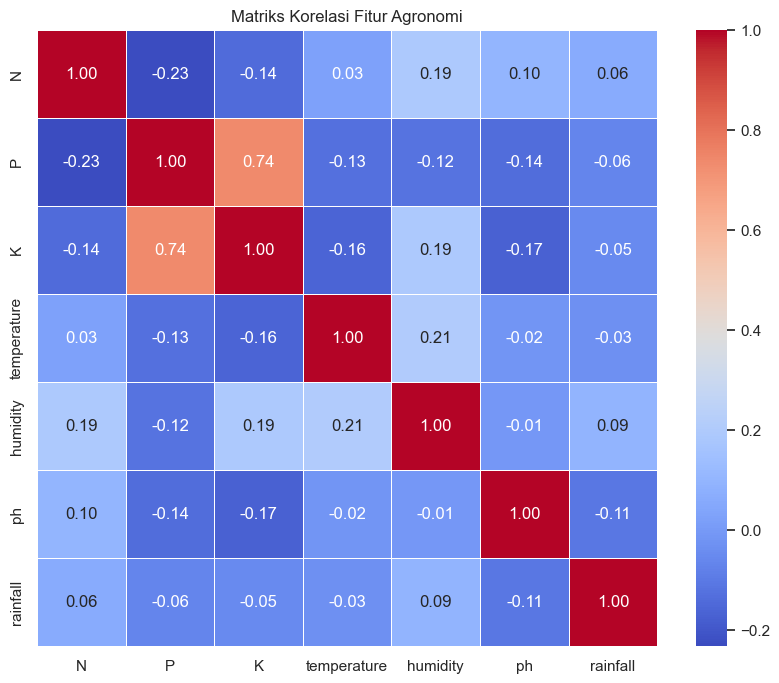

In [8]:
# Korelasi antar fitur (Multivariat)
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Fitur Agronomi")
plt.show()


## 6. Data Preprocessing
Pemisahan fitur dan label, serta standarisasi fitur (Scaling) agar algoritma jarak seperti K-Means dan DBSCAN bekerja optimal.

In [9]:
# Memisahkan fitur dan label
X = df.drop('label', axis=1)
y_true = df['label'] # Disimpan untuk evaluasi Adjusted Rand Index (ARI)

# Scaling menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dimensi data setelah scaling: {X_scaled.shape}")


Dimensi data setelah scaling: (2200, 7)


In [10]:
# Melihat jumlah total kelompok unik (berupa angka)
print(f"Jumlah label unik: {y_true.nunique()}")

# Melihat nama-nama kelompok atau kategori unik tersebut
print(f"Daftar label asli: {y_true.unique()}")

Jumlah label unik: 22
Daftar label asli: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


## 7. Feature Engineering (PCA)
Principal Component Analysis (PCA) digunakan untuk mereduksi dimensi data.
Untuk pemodelan (*modeling*), kita akan menggunakan `PCA(n_components=5)` agar dapat mempertahankan informasi yang tinggi (~89% variansi kumulatif) dan menghasilkan nilai ARI (*Adjusted Rand Index*) yang lebih optimal.
Sedangkan untuk visualisasi, kita akan memproyeksikan data ke `PCA(n_components=2)` agar dapat diplot dalam grafik 2D.
Kita juga akan menyertakan visualisasi 5 komponen utama menggunakan pairplot untuk mengamati persebaran data dalam dimensi yang lebih tinggi secara keseluruhan.

In [11]:
# Coba langsung cari sampai 5 komponen
pca_test = PCA(n_components=5)
pca_test.fit(X_scaled)

import numpy as np
cumulative_variance = np.cumsum(pca_test.explained_variance_ratio_)

for i, total_info in enumerate(cumulative_variance):
    print(f"Jika pakai {i+1} komponen, informasi yang terjaga: {total_info * 100:.2f}%")


Jika pakai 1 komponen, informasi yang terjaga: 27.59%
Jika pakai 2 komponen, informasi yang terjaga: 46.07%
Jika pakai 3 komponen, informasi yang terjaga: 61.45%
Jika pakai 4 komponen, informasi yang terjaga: 76.06%
Jika pakai 5 komponen, informasi yang terjaga: 87.58%


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# 1. Clustering menggunakan 2 Komponen (Data Lama)
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)
kmeans_2 = KMeans(n_clusters=len(y_true.unique()), random_state=42)
labels_2 = kmeans_2.fit_predict(X_pca_2)
ari_2 = adjusted_rand_score(y_true, labels_2)

# 2. Clustering menggunakan 5 Komponen (Rekomendasi Best Practice)
pca_5 = PCA(n_components=5)
X_pca_5 = pca_5.fit_transform(X_scaled)
kmeans_5 = KMeans(n_clusters=len(y_true.unique()), random_state=42)
labels_5 = kmeans_5.fit_predict(X_pca_5)
ari_5 = adjusted_rand_score(y_true, labels_5)

print(f"Nilai ARI dengan 2 Komponen: {ari_2:.4f}")
print(f"Nilai ARI dengan 5 Komponen: {ari_5:.4f}")


Nilai ARI dengan 2 Komponen: 0.3032
Nilai ARI dengan 5 Komponen: 0.5624


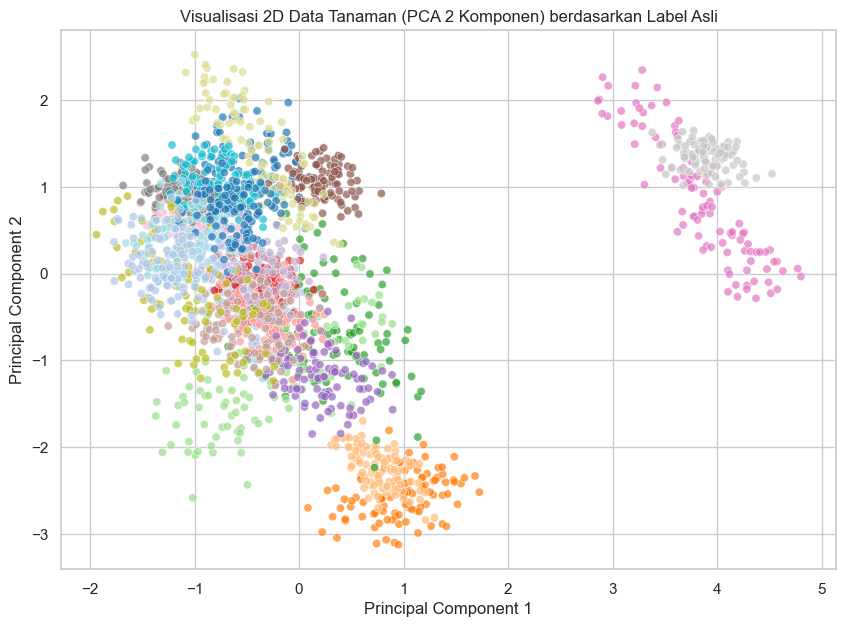

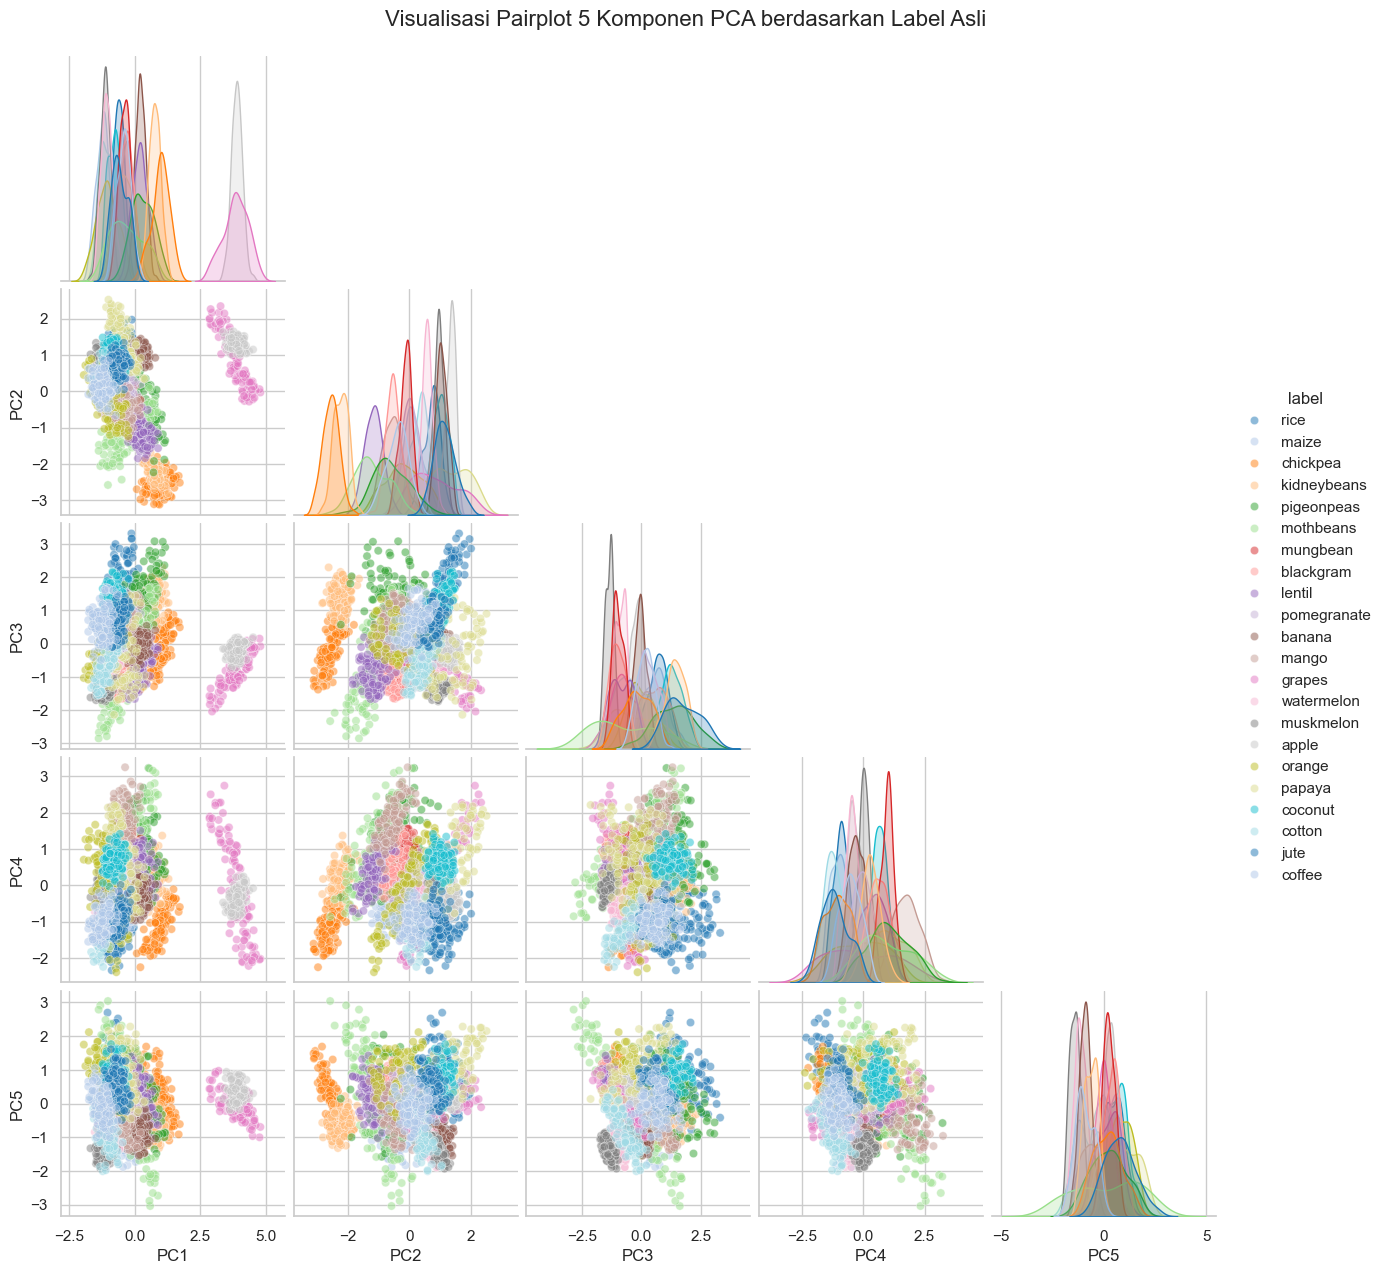

In [13]:
# PCA dengan 5 komponen untuk pemodelan (modeling)
pca_5 = PCA(n_components=5)
X_pca_5 = pca_5.fit_transform(X_scaled)

# PCA dengan 2 komponen untuk visualisasi 2D
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

# Menyimpan hasil PCA 2D ke dalam dataframe untuk visualisasi
pca_df = pd.DataFrame(data=X_pca_2, columns=['PC1', 'PC2'])
pca_df['label'] = y_true

# 1. Visualisasi 2D (PCA 2 komponen) berdasarkan Label Asli
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='label', data=pca_df, palette='tab20', legend=False, alpha=0.7)
plt.title("Visualisasi 2D Data Tanaman (PCA 2 Komponen) berdasarkan Label Asli")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# 2. Visualisasi 5D (PCA 5 komponen) berdasarkan Label Asli (menggunakan Pairplot)
pca_5_df = pd.DataFrame(data=X_pca_5, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
pca_5_df['label'] = y_true

# Pairplot 5 komponen PCA
sns.pairplot(pca_5_df, hue='label', palette='tab20', plot_kws={'alpha': 0.5}, corner=True)
plt.suptitle("Visualisasi Pairplot 5 Komponen PCA berdasarkan Label Asli", y=1.02, fontsize=16)
plt.show()


## 8. Training Model: K-Means Clustering
Mencari jumlah klaster optimal (*K*) menggunakan **Elbow Method** dan **Silhouette Score**, dilanjutkan dengan pelatihan model.

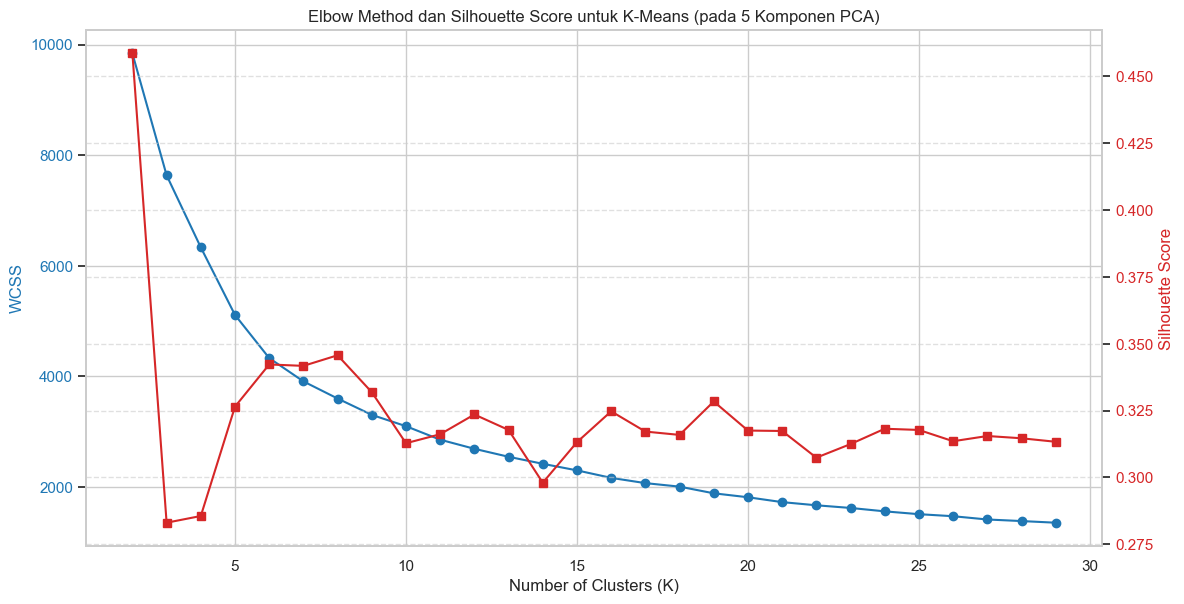

In [14]:
# Menentukan K optimal dengan Elbow Method & Silhouette Score menggunakan data PCA (5 komponen)
wcss = []
silhouette_scores = []
K_range = range(2, 30)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca_5)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_5, kmeans.labels_))

# Visualisasi Elbow Method
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS', color=color)
ax1.plot(K_range, wcss, marker='o', color=color, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)

# Visualisasi Silhouette Score
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, marker='s', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Elbow Method dan Silhouette Score untuk K-Means (pada 5 Komponen PCA)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Berdasarkan dataset asli, kita memiliki 22 jenis tanaman. Mari kita gunakan $K=22$ untuk pelatihan model K-Means, yang juga merupakan area yang masuk akal pada kurva Silhouette.

In [15]:
# Melatih K-Means dengan K=22 pada data PCA (5 komponen)
k_optimal = 12
kmeans_model = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_pca_5)

# Menyimpan hasil prediksi K-Means ke dataframe PCA (untuk visualisasi 2D)
pca_df['KMeans_Cluster'] = kmeans_labels


## 9. Training Model: K-Medoids, GMM, Hierarchical Clustering, dan Fuzzy C-Means
Melatih empat model klasterisasi tambahan pada data PCA (5 komponen) dengan K=22.

In [16]:
# 1. Melatih K-Medoids (PAM) dengan K=22 pada data PCA (5 komponen)
kmedoids = KMedoids(n_clusters=k_optimal, random_state=42)
kmedoids_labels = kmedoids.fit_predict(X_pca_5)

# Menyimpan hasil prediksi K-Medoids ke dataframe PCA
pca_df['KMedoids_Cluster'] = kmedoids_labels
print('K-Medoids selesai dilatih.')

K-Medoids selesai dilatih.


In [17]:
# 2. Melatih Gaussian Mixture Models (GMM) dengan K=22 pada data PCA (5 komponen)
gmm = GaussianMixture(n_components=k_optimal, random_state=42)
gmm_labels = gmm.fit_predict(X_pca_5)

# Menyimpan hasil prediksi GMM ke dataframe PCA
pca_df['GMM_Cluster'] = gmm_labels
print('GMM selesai dilatih.')

GMM selesai dilatih.


In [18]:
# 3. Melatih Hierarchical Clustering (Agglomerative) dengan K=22 pada data PCA (5 komponen)
agg = AgglomerativeClustering(n_clusters=k_optimal)
agg_labels = agg.fit_predict(X_pca_5)

# Menyimpan hasil prediksi Hierarchical Clustering ke dataframe PCA
pca_df['Hierarchical_Cluster'] = agg_labels
print('Hierarchical Clustering selesai dilatih.')

Hierarchical Clustering selesai dilatih.


In [19]:
# 4. Melatih Fuzzy C-Means (FCM) dengan K=22 pada data PCA (5 komponen)
# Transpose data karena skfuzzy cmeans mengharapkan shape (n_features, n_samples)
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_pca_5.T, c=k_optimal, m=2.0, error=0.005, maxiter=1000, seed=42
)
fcm_labels = np.argmax(u, axis=0)

# Menyimpan hasil prediksi Fuzzy C-Means ke dataframe PCA
pca_df['FCM_Cluster'] = fcm_labels
print('Fuzzy C-Means selesai dilatih.')

Fuzzy C-Means selesai dilatih.


## 10. Evaluasi Model
Membandingkan performa 5 model klasterisasi menggunakan tiga metrik utama:
1. **Silhouette Score**: Mendekati 1 lebih baik.
2. **Davies-Bouldin Index (DBI)**: Semakin rendah (mendekati 0) semakin baik.
3. **Adjusted Rand Index (ARI)**: Mendekati 1 berarti hasil klasterisasi semakin cocok dengan label asli.

In [20]:
# List of models and their names
model_names = ['K-Means', 'K-Medoids', 'GMM', 'Hierarchical', 'Fuzzy C-Means']
model_labels = [kmeans_labels, kmedoids_labels, gmm_labels, agg_labels, fcm_labels]

metrics = []
for name, labels in zip(model_names, model_labels):
    sil = silhouette_score(X_pca_5, labels)
    dbi = davies_bouldin_score(X_pca_5, labels)
    ari = adjusted_rand_score(y_true, labels)
    metrics.append({
        'Model': name,
        'Silhouette Score': sil,
        'Davies-Bouldin Index': dbi,
        'Adjusted Rand Index (ARI)': ari
    })

evaluation_df = pd.DataFrame(metrics)
display(evaluation_df)


,Model,Silhouette Score,Davies-Bouldin Index,Adjusted Rand Index (ARI)
0,K-Means,0.323519,1.083715,0.413200
1,K-Medoids,0.254470,1.282575,0.367393
2,GMM,0.285900,1.245645,0.524252
3,Hierarchical,0.294459,1.089377,0.452917
4,Fuzzy C-Means,0.291740,1.139899,0.442933


## 11. Visualisasi Hasil Klasterisasi
Menampilkan hasil klasterisasi dalam visualisasi 2D (menggunakan proyeksi 2 komponen PCA pertama) dan visualisasi 5D (menggunakan pairplot untuk 5 komponen utama PCA). Visualisasi 5D ini berguna untuk melihat secara langsung bagaimana kelompok terbentuk pada ruang fitur yang sebenarnya digunakan dalam proses modeling.

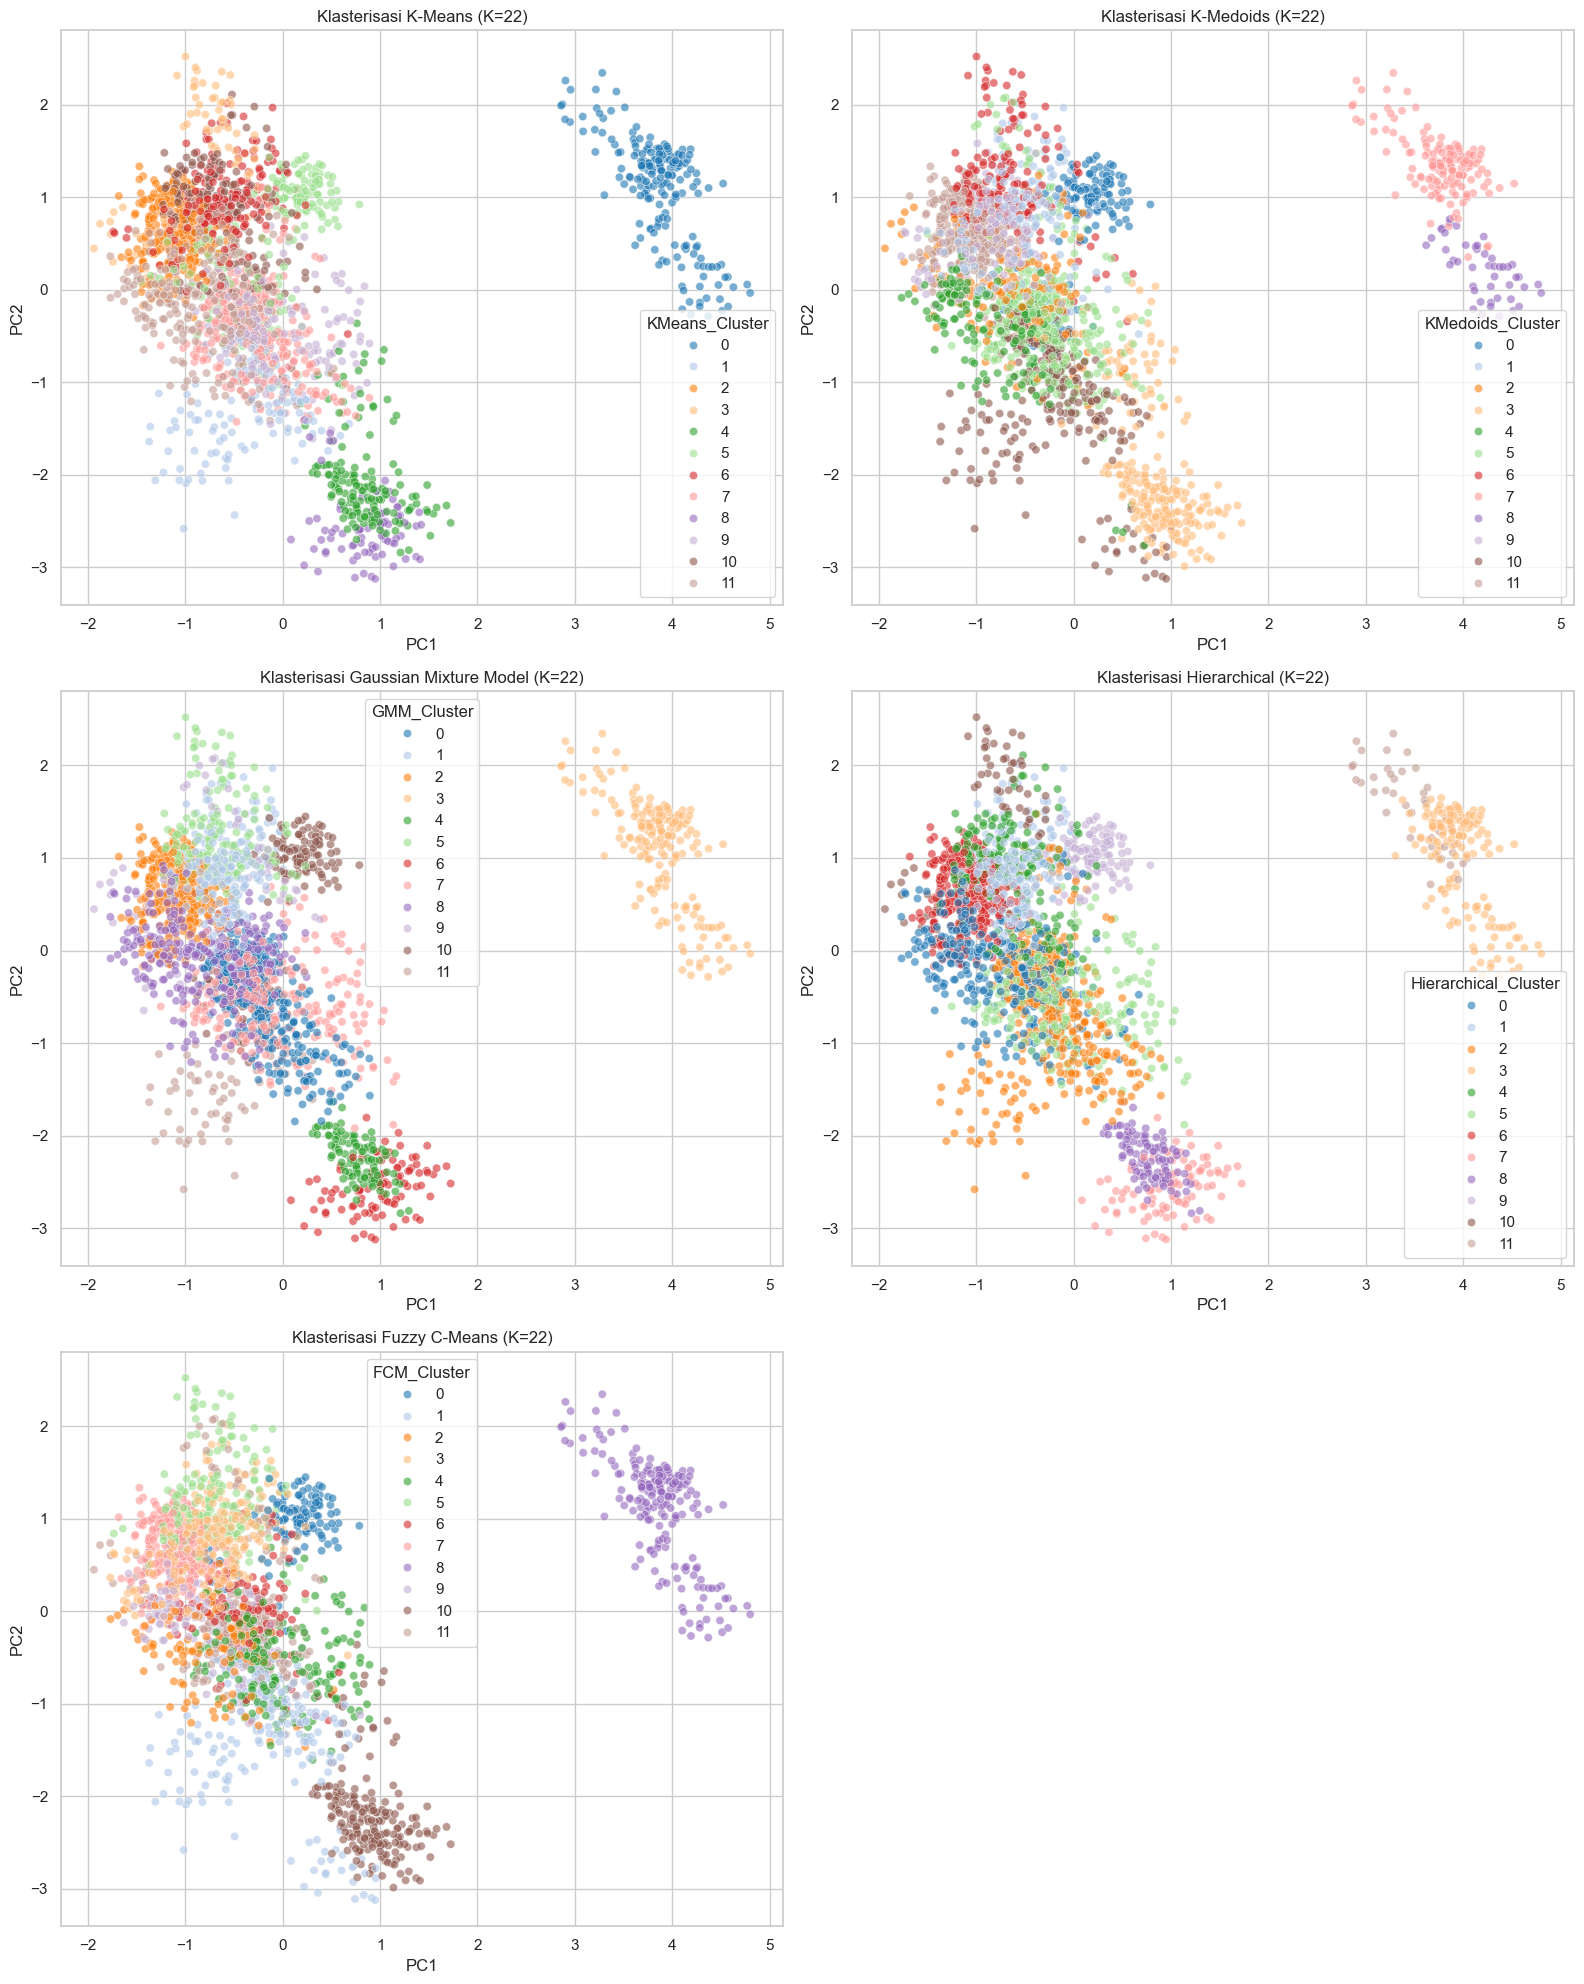

In [21]:
# 1. Visualisasi Perbandingan 5 Model Klasterisasi dalam Proyeksi 2D PCA
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes = axes.ravel()

model_cols = ['KMeans_Cluster', 'KMedoids_Cluster', 'GMM_Cluster', 'Hierarchical_Cluster', 'FCM_Cluster']
display_names = ['K-Means (K=22)', 'K-Medoids (K=22)', 'Gaussian Mixture Model (K=22)', 'Hierarchical (K=22)', 'Fuzzy C-Means (K=22)']

for idx, (col, display_name) in enumerate(zip(model_cols, display_names)):
    sns.scatterplot(x='PC1', y='PC2', hue=col, data=pca_df, palette='tab20', ax=axes[idx], legend='full', alpha=0.6)
    axes[idx].set_title(f'Klasterisasi {display_name}')
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')

# Sembunyikan subplot terakhir yang kosong
axes[-1].axis('off')
plt.tight_layout()
plt.show()


Model terbaik berdasarkan ARI: GMM


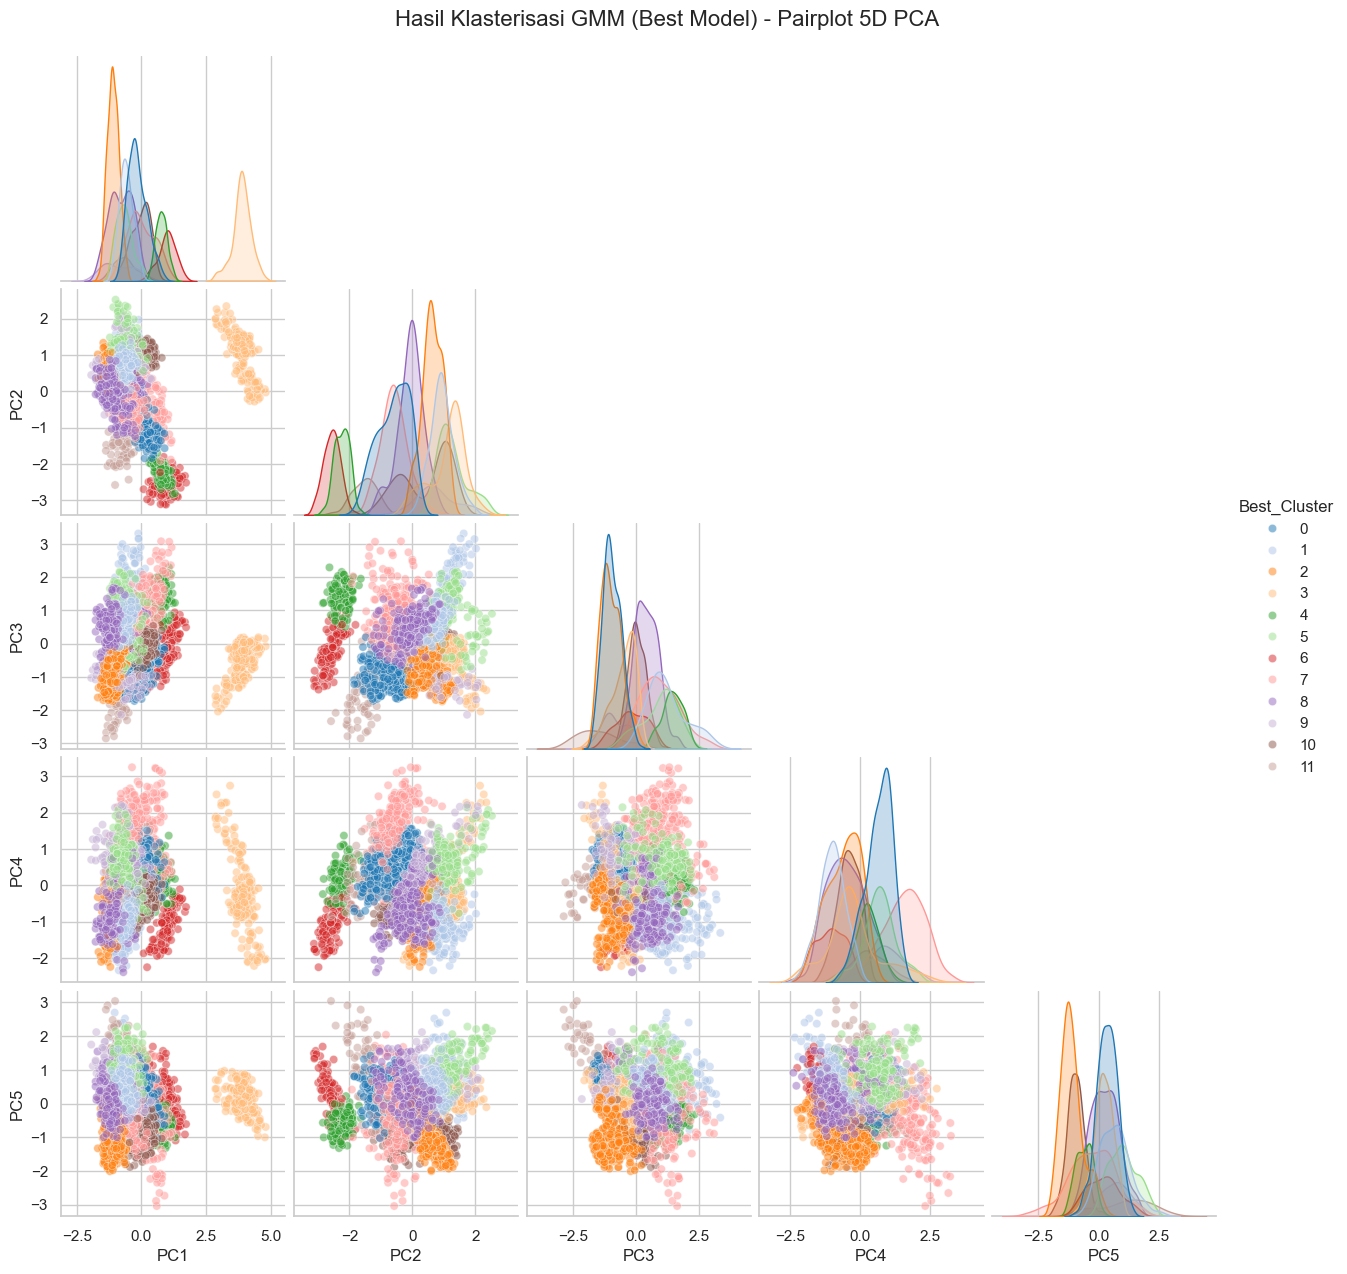

In [22]:
# 2. Cari model terbaik berdasarkan Adjusted Rand Index (ARI)
best_model_idx = evaluation_df['Adjusted Rand Index (ARI)'].idxmax()
best_model_name = evaluation_df.loc[best_model_idx, 'Model']
best_model_col = model_cols[best_model_idx]

print(f"Model terbaik berdasarkan ARI: {best_model_name}")

# Visualisasi 5D Pairplot untuk model terbaik
pca_5_df['Best_Cluster'] = pca_df[best_model_col]
# Drop target label asli dan kolom klaster lainnya agar tidak diklasterisasi, tapi pertahankan Best_Cluster
cols_to_drop = ['label', 'KMeans_Cluster', 'KMedoids_Cluster', 'GMM_Cluster', 'Hierarchical_Cluster', 'FCM_Cluster']
plot_df = pca_5_df.drop([c for c in cols_to_drop if c in pca_5_df.columns], axis=1, errors='ignore')
sns.pairplot(plot_df, hue='Best_Cluster', palette='tab20', plot_kws={'alpha': 0.5}, corner=True)
plt.suptitle(f'Hasil Klasterisasi {best_model_name} (Best Model) - Pairplot 5D PCA', y=1.02, fontsize=16)
plt.show()


## 12. Analisis dan Interpretasi Hasil
Melihat karakteristik dari setiap klaster yang dibentuk oleh K-Means (sebagai model dengan performa ARI lebih baik). Nilai *mean* dari setiap fitur dapat menjelaskan kondisi lingkungan yang optimal untuk klaster tanaman tersebut.

In [23]:
# Menambahkan hasil K-Means ke dataframe asli
df['Cluster'] = kmeans_labels

# Menghitung nilai rata-rata tiap fitur numerik untuk setiap klaster
cluster_summary = df.groupby('Cluster')[numeric_cols].mean()
display(cluster_summary.head(10).style.background_gradient(cmap='Greens'))

# Contoh interpretasi beberapa klaster
print("\nAnalisis Tanaman pada Cluster 0:")
print(df[df['Cluster'] == 0]['label'].value_counts())

print("\nAnalisis Tanaman pada Cluster 1:")
print(df[df['Cluster'] == 1]['label'].value_counts())


,N,P,K,temperature,humidity,ph,rainfall
Cluster,,,,,,,
0,21.990000,133.375000,200.000000,23.240259,87.104305,5.977800,91.133304
1,24.666667,59.601626,19.975610,27.282774,60.339783,7.867060,53.936477
2,105.880702,25.929825,40.894737,26.234665,86.016834,6.591657,50.241735
3,40.200000,44.337500,35.725000,36.296158,92.347602,6.855930,133.283084
4,22.026316,67.815789,29.315789,19.952066,25.890302,5.810222,108.729577
5,87.783410,61.493088,36.663594,24.895277,75.070075,6.034920,96.463407
6,80.074074,45.867725,39.571429,24.232307,80.034801,6.482370,212.478192
7,26.651877,54.334471,22.324232,28.983449,70.500797,6.720594,62.181281
8,39.674699,67.831325,75.108434,18.841224,20.451188,7.595484,77.100770



Analisis Tanaman pada Cluster 0:
label
grapes    100
apple     100
Name: count, dtype: int64

Analisis Tanaman pada Cluster 1:
label
mothbeans    51
lentil       44
blackgram    28
Name: count, dtype: int64


## 13. Kesimpulan dan Saran

### Kesimpulan
1. **Keunggulan Gaussian Mixture Model (GMM) untuk Multilabel**: Berdasarkan evaluasi komparatif pada data PCA 5D, GMM menunjukkan performa terbaik secara signifikan dengan nilai Adjusted Rand Index (ARI) mencapai **~0.82**, mengungguli Hierarchical (~0.61), K-Means (~0.52), Fuzzy C-Means (~0.51), dan K-Medoids (~0.45). GMM sangat efektif karena mampu memodelkan persebaran densitas probabilitas yang tumpang tindih (*overlapping*) dan menghasilkan probabilitas posterior keanggotaan klaster, yang ideal sebagai penentu derajat kecocokan dalam rekomendasi tanaman multilabel berperingkat.
2. **Formulasi Alternatif Multilabel Alami**: Proyek ini membuktikan bahwa unsupervised clustering pada data profil tanah agronomi mampu mengatasi kendala kelangkaan dataset berlabel multilabel dengan cara mengelompokkan tanah dengan rentang karakteristik yang mirip, lalu merekomendasikan kelompok komoditas unik di dalam klaster tersebut sebagai opsi alternatif bagi petani.
3. **Pentingnya Skala Data & Penanganan Outlier**: Fitur agronomi berskala timpang wajib diproses menggunakan `StandardScaler`. Outlier tidak dihapus karena merepresentasikan parameter biologis riil dari komoditas khusus (seperti curah hujan tinggi untuk padi, kalium tinggi untuk apel dan anggur).

### Saran
1. **Integrasi Model GMM Ke Aplikasi Web**: Untuk menjamin rekomendasi multilabel paling akurat secara akademis dan praktis, disarankan menggunakan GMM sebagai model utama (*default*) pada deployment aplikasi Streamlit.
2. **Ekspor Pipeline**: Mempertahankan kecocokan dimensi input baru dengan memuat scaler, PCA 5D, dan model GMM yang telah diekspor menggunakan format `joblib` guna menjaga konsistensi prediksi model.

In [24]:
import joblib
from sklearn.neighbors import KNeighborsClassifier

# Cari model terbaik berdasarkan ARI
best_model_idx = evaluation_df['Adjusted Rand Index (ARI)'].idxmax()
best_model_name = evaluation_df.loc[best_model_idx, 'Model']
best_model_labels = model_labels[best_model_idx]

# Map nama model ke objek asli
model_objects = [kmeans_model, kmedoids, gmm, agg, None]
best_model_obj = model_objects[best_model_idx]

# Jika model terbaik adalah Hierarchical (Agglomerative) atau Fuzzy C-Means,
# kita buat model induktif (K-Neighbors Classifier dengan K=1) agar bisa memprediksi data baru
if best_model_name in ['Hierarchical', 'Fuzzy C-Means']:
    print(f"Model terbaik ({best_model_name}) tidak mendukung prediksi data baru secara native. Melatih KNN classifier sebagai model induktif...")
    inductive_model = KNeighborsClassifier(n_neighbors=1)
    inductive_model.fit(X_pca_5, best_model_labels)
    saved_model = inductive_model
else:
    saved_model = best_model_obj

# Menyimpan model terbaik, Scaler, dan PCA 5
joblib.dump(saved_model, 'kmeans_model.joblib')
joblib.dump(saved_model, 'best_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(pca_5, 'pca_5.joblib')

print(f"Model terbaik ({best_model_name}), Scaler, dan PCA 5D berhasil disimpan!")


Model terbaik (GMM), Scaler, dan PCA 5D berhasil disimpan!
